<a href="https://colab.research.google.com/github/ArielaLevkov/ImageProcessing_TA/blob/main/exercises/ImageProcessingEx_03_BinaryImages_solved.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div dir="rtl">

# מטלה 3 - פתרון:

<dir>

In [1]:
import os
import requests
from io import BytesIO
import numpy as np
import matplotlib.pyplot as plt
import PIL

In [2]:
GITHUB_PATH = 'https://raw.githubusercontent.com/ArielaLevkov/ImageProcessing_TA/main/images/'

def read_file(file_name:str, file_path:str=GITHUB_PATH) -> np.ndarray:
    '''
    Accept an image file name (defaulty located in GitHub) and return the image
    in a numpy array.

    Args:
        file_name: the file name
        file_path: the file path.. Default value is Doron's Github repo.

    Returns:
        the image converted into a Numpy array.
    '''
    file_path = os.path.join(file_path, file_name)
    response = requests.get(file_path)
    fp = BytesIO(response.content)

    img_pil = PIL.Image.open(fp)
    return np.array(img_pil, dtype='int16')

In [3]:
def pretty_print(img):
    ''' pretty printing of binary imagees and connected components - by
    replacing zeros with whitespaces.
    Args:
        img: image in float format (range: 0..1) - the source binary image
        file_path: the file path.. Default value is Doron's Github repo.

    Returns:
        the image converted into a Numpy array.
    '''
    for r in range(img.shape[0]):
        l = [str(img[r,c].astype(np.int16)) if img[r,c]>0 else ' ' for c in range(img.shape[1])]
        print(''.join(map(str, l)))

In [4]:
def plot_images(img1:np.array, img2:np.array):
    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 6))
    axes[0].imshow(img1,  cmap='gray')
    axes[1].imshow(img2,  cmap='gray')

## `tag_connected_components`

In [5]:
def tag_connected_components(img: np.array) -> np.array:
    '''
    This function receives a binary image and finds the connected components
    in it and returns a matrix with the same size in which each connected
    componnent is tagged with a different label. The tags should be sequential.

    Args:
        img: image in float format (range: 0..1) - the source binary image

    Returns:
        img_new: in float format (range: 0..1) - the image with components
                 tagging in a 2 dimensional matrice
    '''
    ######################################################################
    # TODO: Implement The tag connected components algorithm.
    ######################################################################
    '''Step 1: creating:
        img_new - image with tagging of components. In step 4, we will merge
                connected components.
        equiv - the connection matrix - equiv(i, j) == 1 if a component labeled
                i is connected to a component labeled j.
    '''
    img_nrows, img_ncols = img.shape
    img_new = np.zeros(shape=(img_nrows, img_ncols))
    equiv_vec = []
    maxtag = 0
    for r in range(1, img_nrows-1):
        for c in range(1, img_ncols-1):
            if img[r, c] == 0:
                continue
            up = int(img_new[r-1, c])
            left = int(img_new[r, c-1])
            if up == 0 and left == 0:
                maxtag = maxtag + 1
                equiv_vec.append((maxtag, maxtag))
                img_new[r, c] = maxtag
            elif up > 0 and left == 0:
                img_new[r, c] = up
            elif up == 0 and left > 0:
                img_new[r, c] = left
            elif up > 0 and left > 0 and up == left:
                img_new[r, c] = up
            else:  # up != left
                img_new[r, c] = up
                equiv_vec.append((left, up))
                equiv_vec.append((up, left))

    equiv = np.zeros(shape=(maxtag, maxtag),dtype=np.int16)
    for (tag1, tag2) in equiv_vec:
        equiv[tag1-1, tag2-1] = 1
    '''Step 2: create equiv2 - the full connection matrix - equiv2(i, j) == 1 if
    equiv(i, k) == 1 and equiv(j, k) == 1. the procedure is repeated till all
    indirect connections are included.
    '''
    while True:
        equiv2 = np.minimum(equiv @ equiv, 1);
        if (equiv == equiv2).all():
            break
        equiv = equiv2

    '''Step 3: create cv - the conversion vector between current tag and new tag
    of the connected element.
    '''
    cv = equiv2[0, :];
    tagmin = 1;
    cv_len = len(cv);
    for i in range(1, cv_len):
        if cv[i] == 0:
            tagmin = tagmin + 1
            cv = cv + tagmin*equiv2[i,:]

    '''Step 4: modify img_new convert non-connected to connected components.
    '''
    for r in range(1, img_nrows):
        for c in range(1, img_ncols):
            if img_new[r, c] > 0:
                    img_new[r,c] = cv[int(img_new[r,c])-1]
    ######################################################################
    #                            END OF YOUR CODE                        #
    ######################################################################

    return img_new

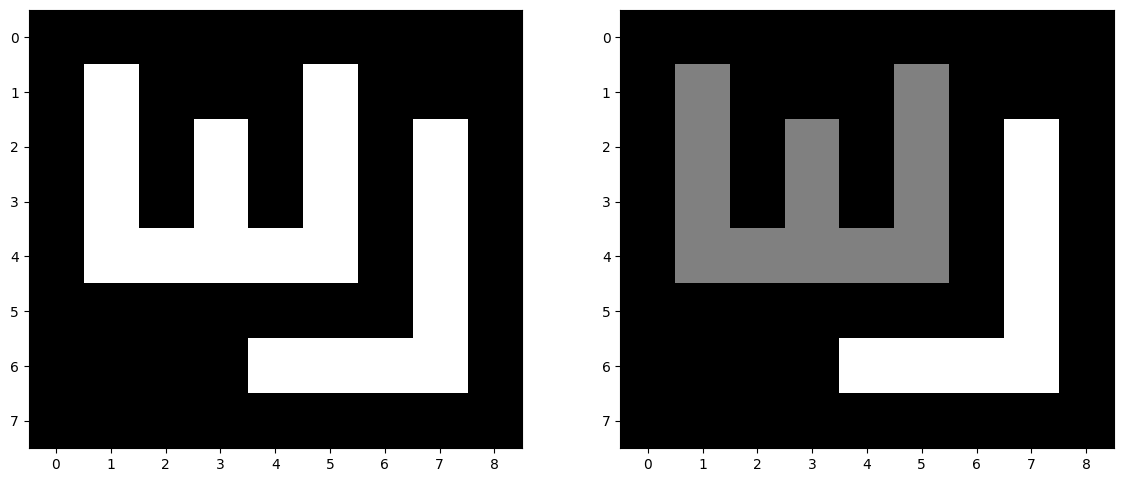

In [6]:
img = np.array([[0,0,0,0,0,0,0,0,0],
       [0,1,0,0,0,1,0,0,0],
       [0,1,0,1,0,1,0,1,0],
       [0,1,0,1,0,1,0,1,0],
       [0,1,1,1,1,1,0,1,0],
       [0,0,0,0,0,0,0,1,0],
       [0,0,0,0,1,1,1,1,0],
       [0,0,0,0,0,0,0,0,0]])
img_n = tag_connected_components(img)
plot_images(img, img_n)

In [7]:
pretty_print(img_n)

         
 1   1   
 1 1 1 2 
 1 1 1 2 
 11111 2 
       2 
    2222 
         


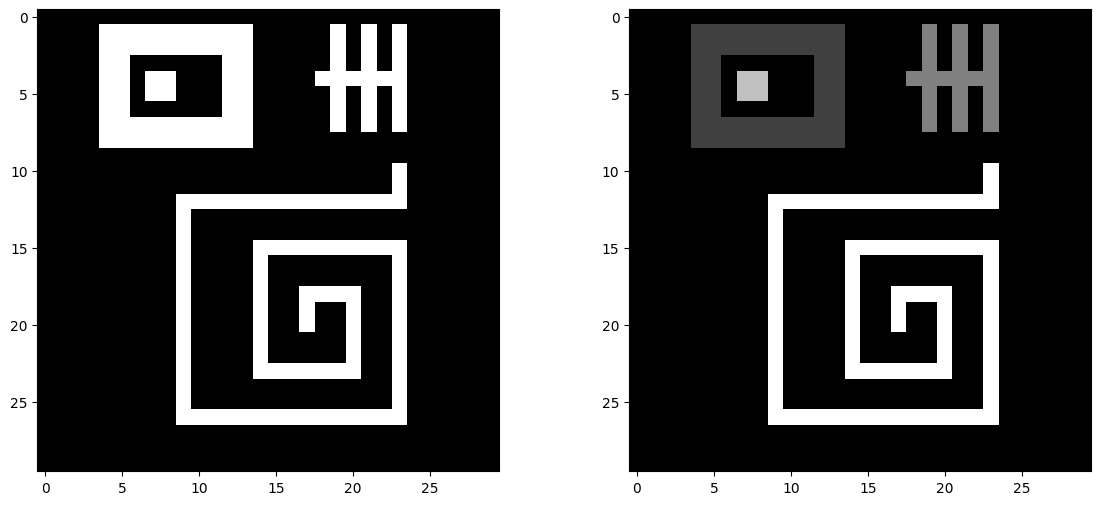

In [8]:
img = read_file('binary1.tiff') / 255
img_n = tag_connected_components(img)
plot_images(img, img_n)

In [9]:
pretty_print(img_n)

                              
    1111111111     2 2 2      
    1111111111     2 2 2      
    11      11     2 2 2      
    11 33   11    222222      
    11 33   11     2 2 2      
    11      11     2 2 2      
    1111111111     2 2 2      
    1111111111                
                              
                       4      
                       4      
         444444444444444      
         4                    
         4                    
         4    4444444444      
         4    4        4      
         4    4        4      
         4    4  4444  4      
         4    4  4  4  4      
         4    4  4  4  4      
         4    4     4  4      
         4    4     4  4      
         4    4444444  4      
         4             4      
         4             4      
         444444444444444      
                              
                              
                              


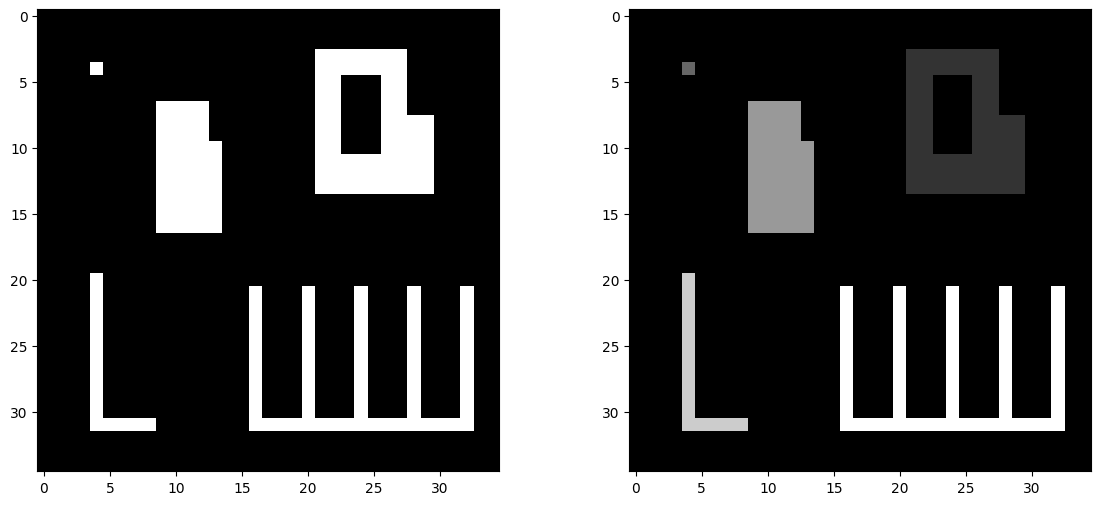

In [10]:
img = read_file('binary2.tiff') / 255
img_n = tag_connected_components(img)
plot_images(img, img_n)

In [11]:
pretty_print(img_n)

                                   
                                   
                                   
                     1111111       
    2                1111111       
                     11   11       
                     11   11       
         3333        11   11       
         3333        11   1111     
         3333        11   1111     
         33333       11   1111     
         33333       111111111     
         33333       111111111     
         33333       111111111     
         33333                     
         33333                     
         33333                     
                                   
                                   
                                   
    4                              
    4           5   5   5   5   5  
    4           5   5   5   5   5  
    4           5   5   5   5   5  
    4           5   5   5   5   5  
    4           5   5   5   5   5  
    4           5   5   5   5   5  
    4           5   5   5   

## `skeletonizeImage `

In [12]:
def neighbours(dists, r, c):
    ''' This function returns the 4-neighbours of a pixel
    '''
    vec_4neighbours = [
        dists[r, c-1], dists[r, c+1], dists[r-1, c], dists[r+1, c]]
    return vec_4neighbours
def skeletonizeImage (img: np.array) -> np.array:
    '''
    This function receives a binary image and returns a new binary image with
    skeletonize objects.

    Args:
        img: image in float format (range: 0..1) - the source binary image

    Returns:
        img_new: in float format (range: 0..1) - the image with skeleton
                    in a 2 dimensional matrice.
    '''
    ######################################################################
    # TODO: Implement The skeletonize algorithm.
    ######################################################################
    img_nrows, img_ncols = img.shape

    ''' Step 1: creating dists - and fill it with dists from border
    '''
    dists = img.copy()
    dist_changed = True
    dist = 0
    while dist_changed:
        dist = dist + 1
        dist_changed = False
        for r in range(1, img_nrows-1):
            for c in range (1, img_ncols-1):
                if img[r, c] == 0:
                    continue        # if an hole
                vec_4neighbours = neighbours(dists, r, c)
                if min(vec_4neighbours) >= dist:
                    dists[r, c] = dist + 1
                    dist_changed = True

    ''' Step 2: mark skeleton pixels
    '''
    img_new = np.zeros(shape=(img_nrows, img_ncols))
    for r in range (1, img_nrows-1):
        for c in range (1, img_ncols-1):
            vec_4neighbours = neighbours(dists, r, c);
            if (dists[r, c] > 0) and (dists[r, c] >= max(vec_4neighbours)):
                img_new[r, c] = 1
    ######################################################################
    #                            END OF YOUR CODE                        #
    ######################################################################
    return img_new

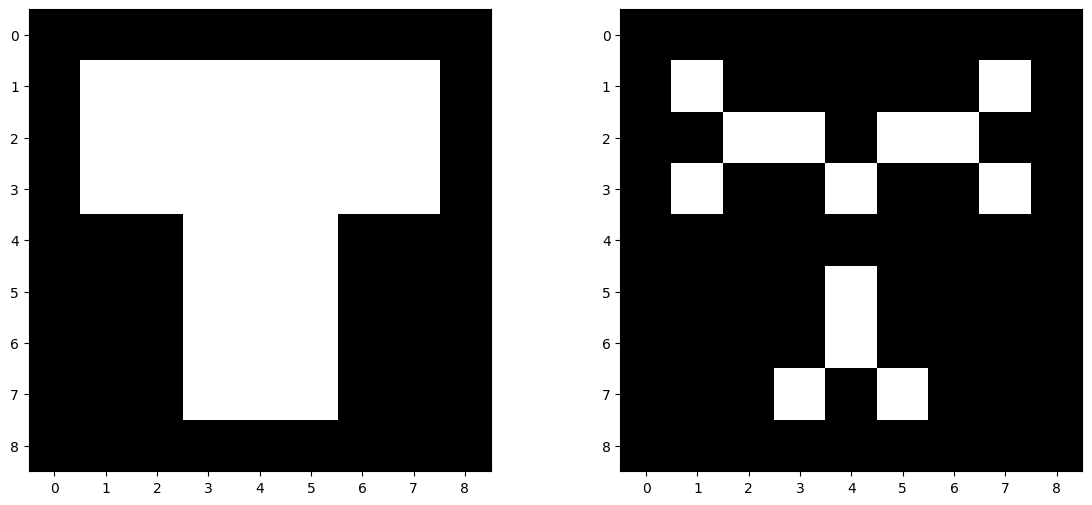

In [13]:
img = np.array([[0,0,0,0,0,0,0,0,0],
                [0,1,1,1,1,1,1,1,0],
                [0,1,1,1,1,1,1,1,0],
                [0,1,1,1,1,1,1,1,0],
                [0,0,0,1,1,1,0,0,0],
                [0,0,0,1,1,1,0,0,0],
                [0,0,0,1,1,1,0,0,0],
                [0,0,0,1,1,1,0,0,0],
                [0,0,0,0,0,0,0,0,0]])
img_new = skeletonizeImage(img)
plot_images(img, img_new)

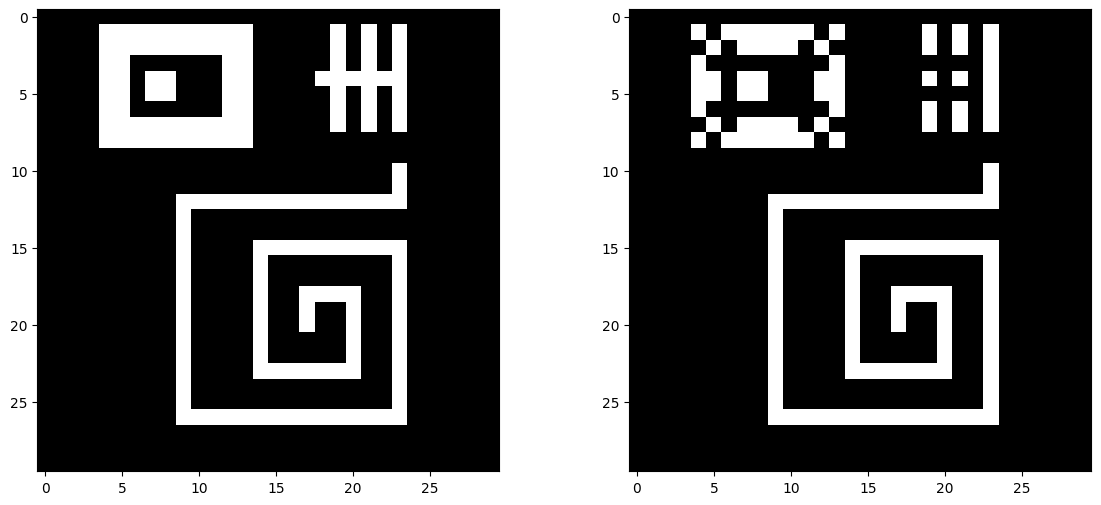

In [14]:
img = read_file('binary1.tiff') / 255
img_n = skeletonizeImage(img)
plot_images(img, img_n)

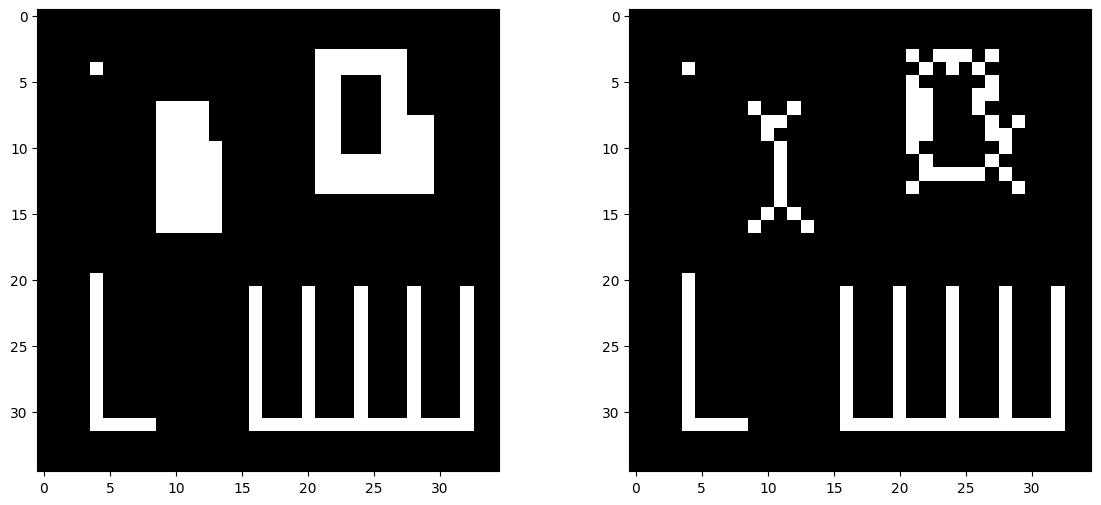

In [15]:
img = read_file('binary2.tiff') / 255
img_n = skeletonizeImage(img)
plot_images(img, img_n)